In [1]:
import numpy as np
from pathlib import Path
import sys

project_root = Path('/home/telmo/phd_seminar')
sys.path.append(str(project_root))

from HECATE import HECATE

from get_data import *
from plots import *
from utils import *

from multi_night_analysis import multi_night_analysis

In [2]:
stellar_params = {
                "Teff":4969, "Teff_err":43,   #effective temperature [K]
                "logg":4.60, "logg_err":0.01, #superficial gravity [dex]
                "FeH":-0.07, "FeH_err":0.02,  #metallicity [dex]
                "P_rot":2.21857312,           #rotation period [d]
                "R_star":0.766,               #radius [solar radii]
                "inc_star":71.87              #stellar inclination [º]
                }

planet_params = {
                "P_orb":2.21857312,           #orbital period [d]
                "a_R":8.76863,                #system scale [stellar radii]
                "Rp_Rs":0.1602,               #planet-to-star radius ratio 
                "t0":53988.30339,             #mid-transit time [d]
                "e":0,                        #orbital eccentricity
                "w":90,                       #argument of periastron [º]
                "inc_planet":85.465,          #planet inclination [º]
                "lbda":-1.00,                 #spin-orbit angle [º]
                "dfp": -0.002424              #mid-transit phase shift
                }

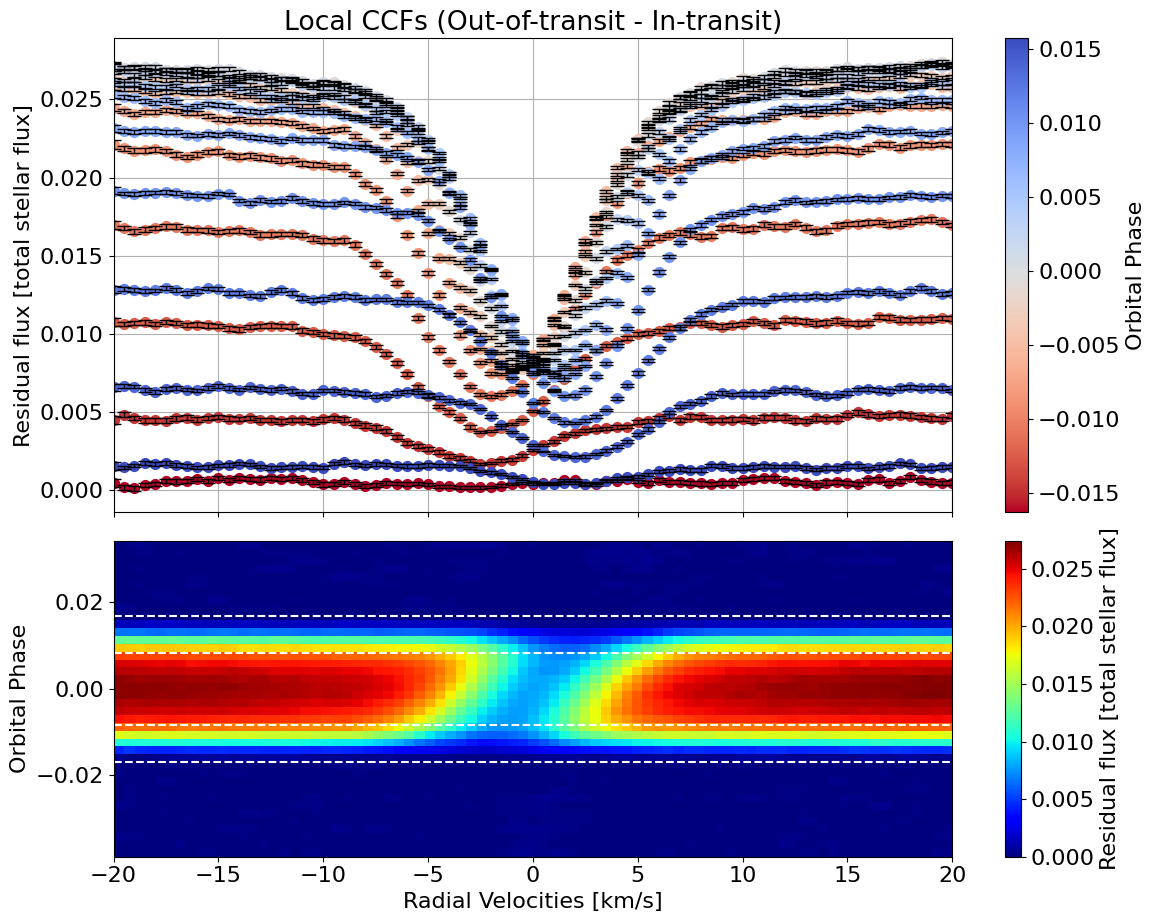

In [3]:
CCFs, time, airmass, berv, bervmax, snr, list_ccfs = get_CCFs(planet_params, day='2021-08-11', plot=False)

hecate11 = HECATE(planet_params, stellar_params, time, CCFs, None)

plot = {"SOAP":False, "fits_initial_CCF":False, 
        "sys_vel_ccf":False, "avg_out_of_transit_CCF":False, 
        "local_CCFs":True, "photometrical_rescale":False}

ccf_type = "white light"
model_fit = "modified Gaussian"

local_CCFs, CCFs_flux_corr, CCFs_sub_all, avg_out_of_transit_CCF = hecate11.extract_local_CCF(model_fit, plot, save=None)

In [4]:
master_results_11 = hecate11.get_profile_parameters(profiles=avg_out_of_transit_CCF, data_type="CCF", 
                                                    observation_type="master", model="modified Gaussian", 
                                                    print_output=False, plot_fit=False)

local_results_11 = hecate11.get_profile_parameters(profiles=local_CCFs, data_type="CCF", 
                                                   observation_type="local", model="modified Gaussian", 
                                                   print_output=False, plot_fit=False)

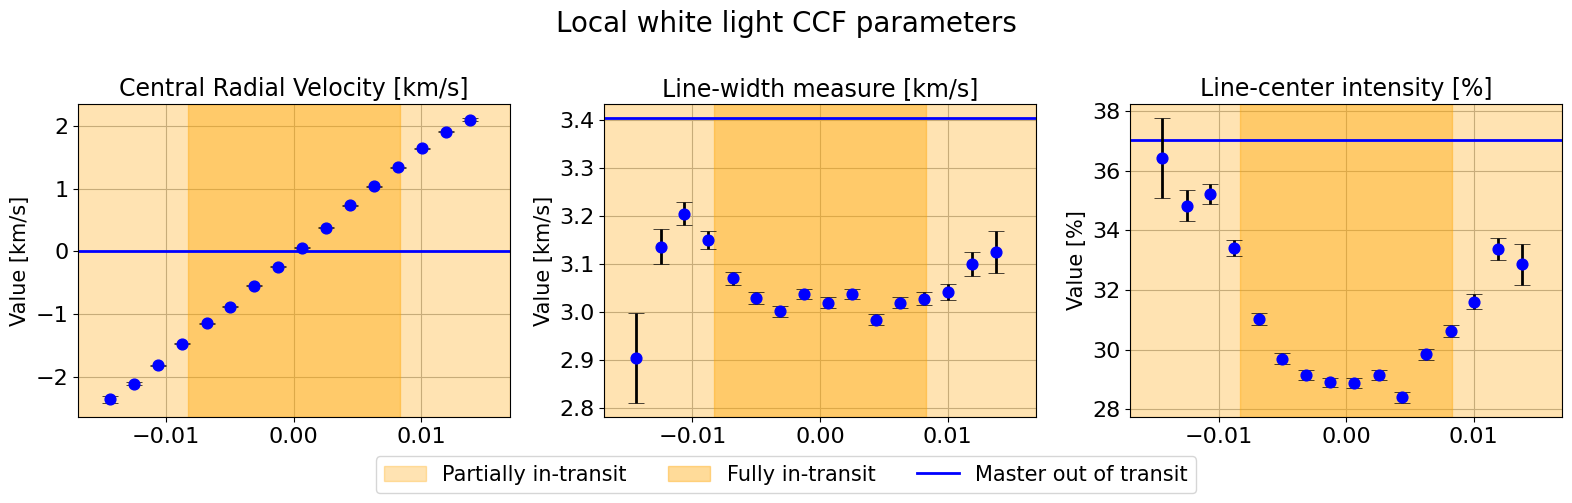

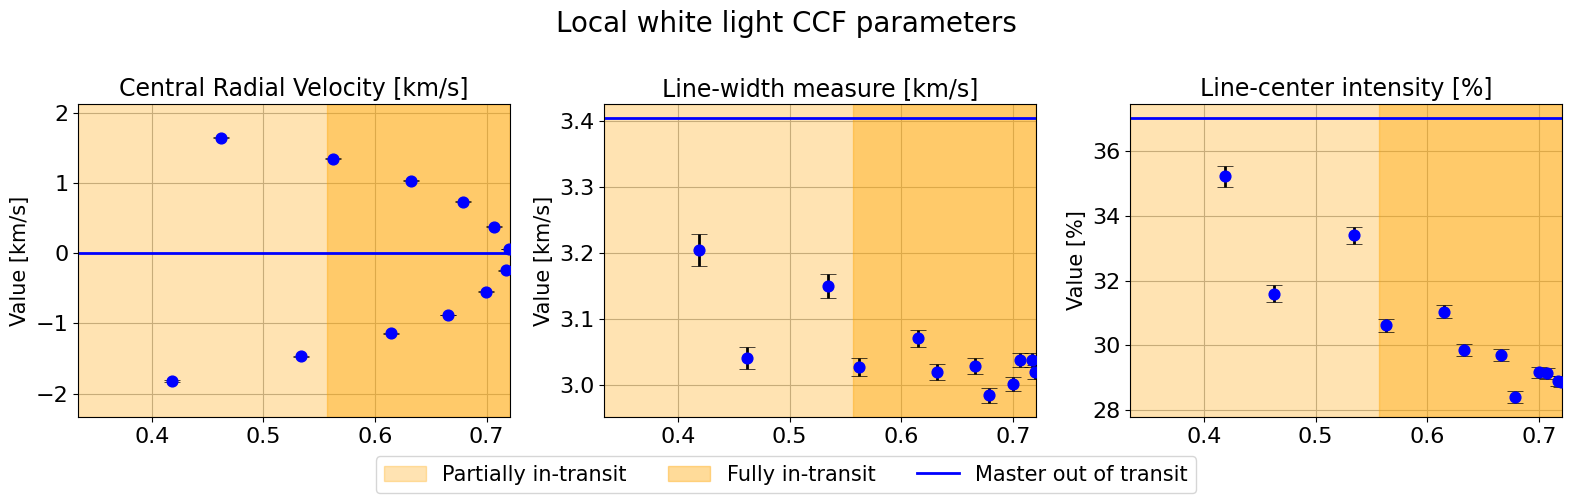

In [5]:
indices_final_11 = np.where(local_results_11['R2'] >= 0.95)[0]

local_params_11 = [local_results_11['central_rv'], local_results_11['width'], local_results_11['intensity']]
master_params_11 = [master_results_11['central_rv'], master_results_11['width'], master_results_11['intensity']]

hecate11.plot_local_params(indices_final_11, local_params_11, master_params_11, suptitle=r"Local white light CCF parameters")

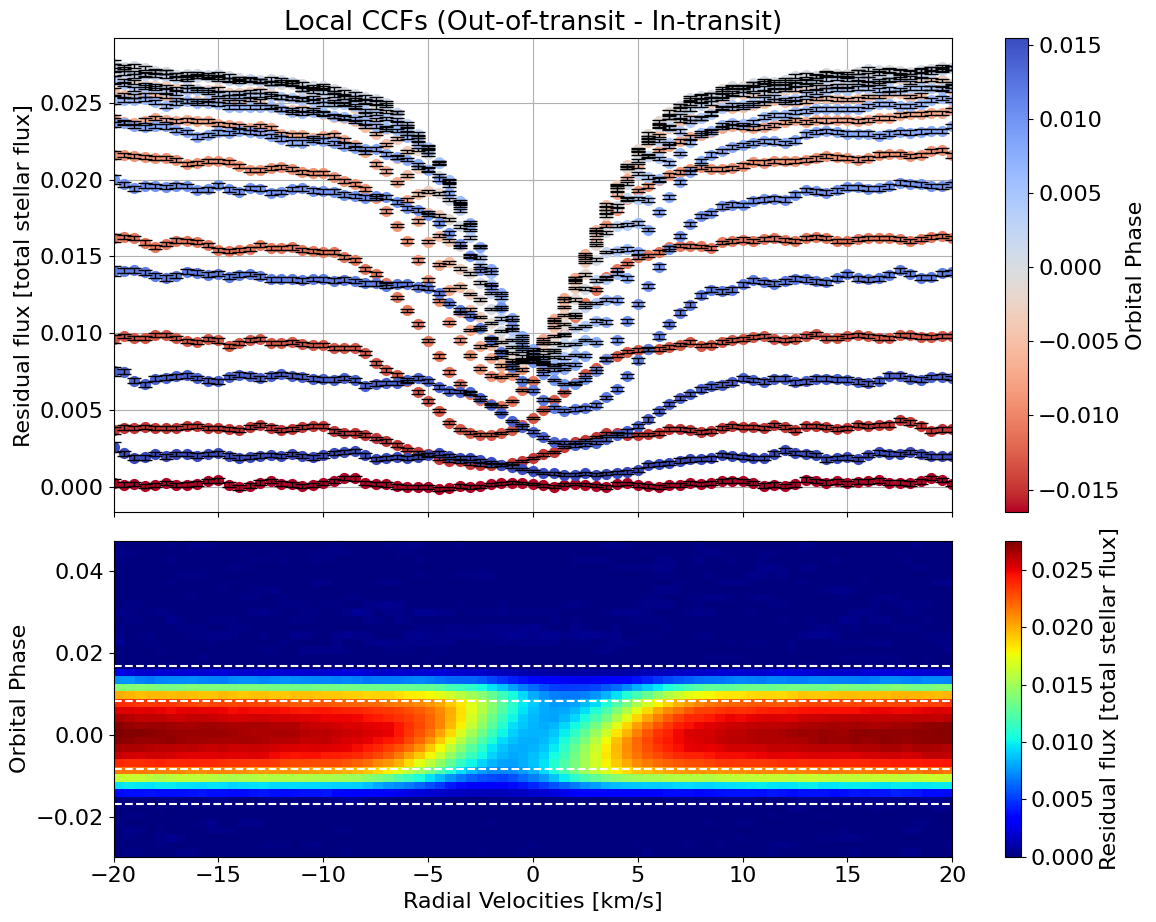

In [6]:
CCFs, time, airmass, berv, bervmax, snr, list_ccfs = get_CCFs(planet_params, day='2021-08-31', plot=False)

hecate31 = HECATE(planet_params, stellar_params, time, CCFs, None)

plot = {"SOAP":False, "fits_initial_CCF":False, 
        "sys_vel_ccf":False, "avg_out_of_transit_CCF":False, 
        "local_CCFs":True, "photometrical_rescale":False}

ccf_type = "white light"
model_fit = "modified Gaussian"

local_CCFs, CCFs_flux_corr, CCFs_sub_all, avg_out_of_transit_CCF = hecate31.extract_local_CCF(model_fit, plot, save=None)

In [7]:
master_results_31 = hecate31.get_profile_parameters(profiles=avg_out_of_transit_CCF, data_type="CCF", 
                                                    observation_type="master", model="modified Gaussian", 
                                                    print_output=False, plot_fit=False)

local_results_31 = hecate31.get_profile_parameters(profiles=local_CCFs, data_type="CCF", 
                                                    observation_type="local", model="modified Gaussian", 
                                                    print_output=False, plot_fit=False)

Could not fit phase -0.016
Optimal parameters not found: The maximum number of function evaluations is exceeded.


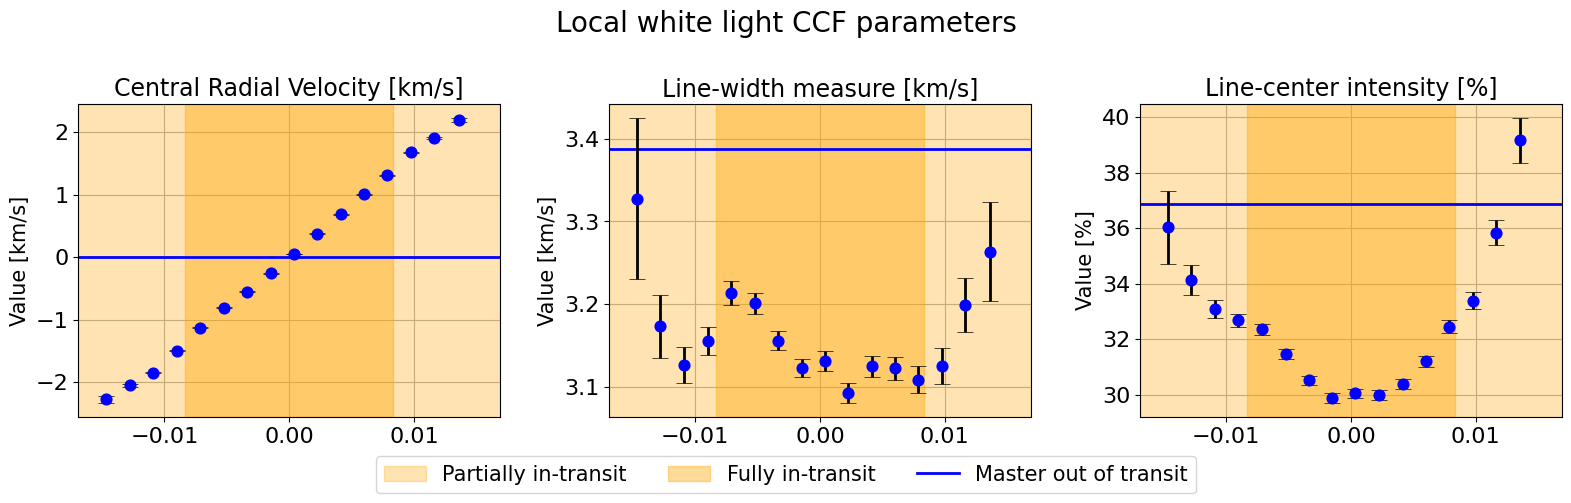

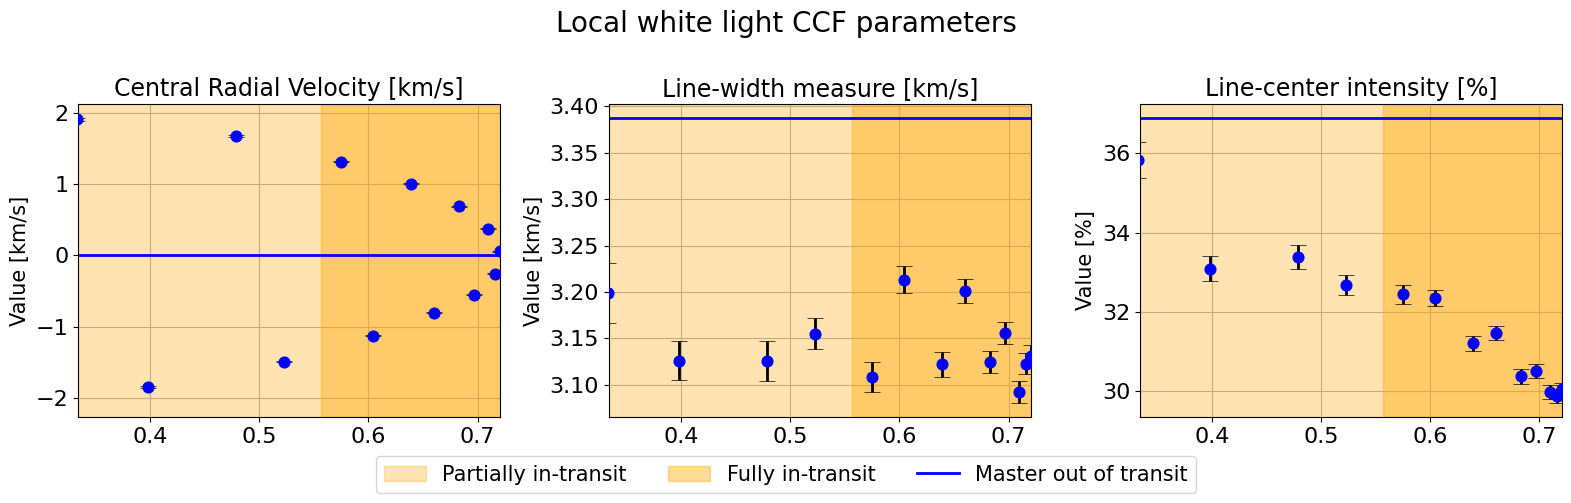

In [8]:
indices_final_31 = np.where(local_results_31['R2'] >= 0.95)[0]

local_params_31 = [local_results_31['central_rv'], local_results_31['width'], local_results_31['intensity']]
master_params_31 = [master_results_31['central_rv'], master_results_31['width'], master_results_31['intensity']]

hecate31.plot_local_params(indices_final_31, local_params_31, master_params_31, suptitle=r"Local white light CCF parameters")

In [9]:
night_data_11 = {
    'hecate': hecate11,
    'indices': indices_final_11,
    'local_params': np.array(local_params_11),
    'master_params': np.array(master_params_11),
    'color': "blue",
    'label': "2021-08-11"
        }

night_data_31 = {
    'hecate': hecate31,
    'indices': indices_final_31,
    'local_params': np.array(local_params_31),
    'master_params': np.array(master_params_31),
    'color': "red",
    'label': "2021-08-31"
        }

In [10]:
night_data = {"2021-08-11": night_data_11,
              "2021-08-31": night_data_31}

In [11]:
mult_night = multi_night_analysis(night_data, data_type='CCF')

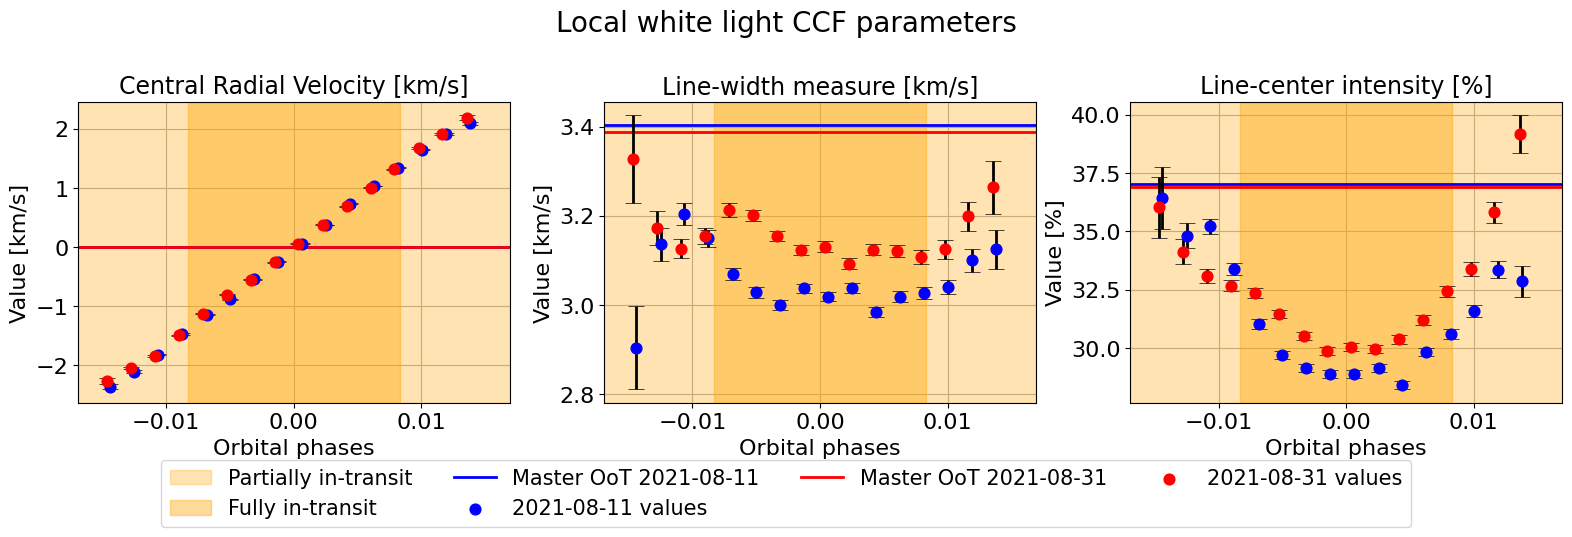

{}

In [12]:
mult_night.plot_parameters(param_type='phases', 
                            fit_each_night=False, 
                            fit_combined=False, 
                            combined_night_names=None, 
                            plot_nested=False, 
                            suptitle="Local white light CCF parameters")

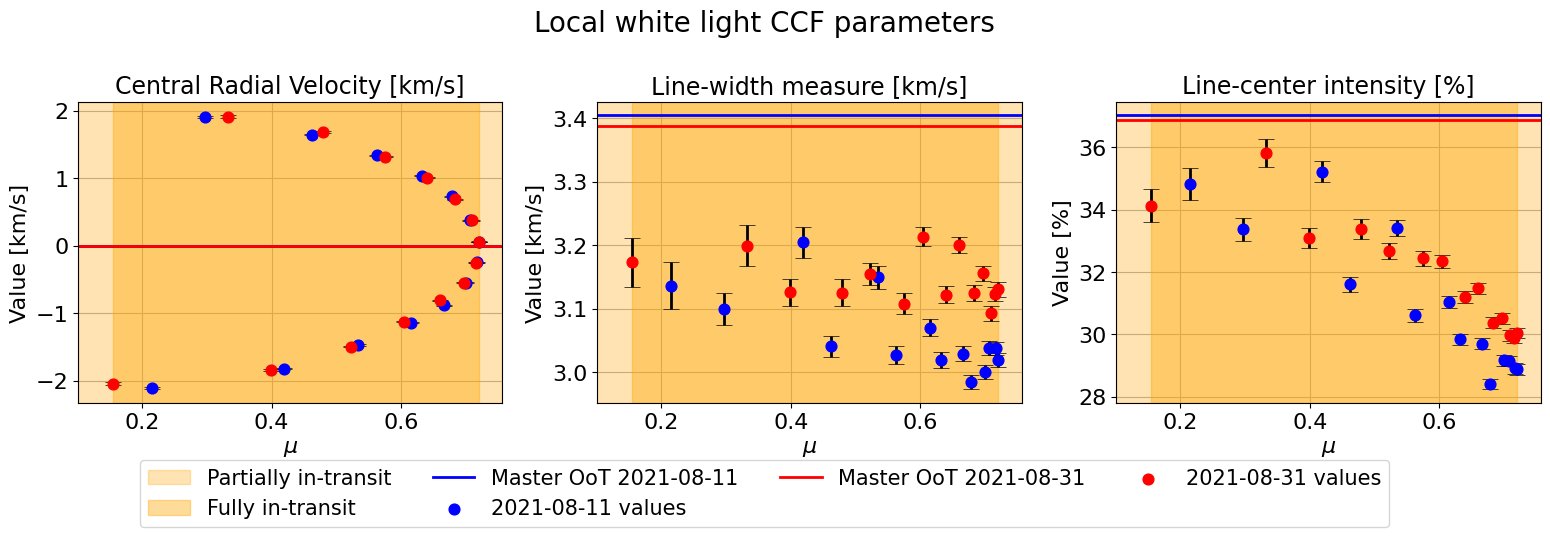

{}

In [13]:
mult_night.plot_parameters(param_type='mu', 
                            fit_each_night=False, 
                            fit_combined=False, 
                            combined_night_names=None, 
                            plot_nested=False, 
                            suptitle="Local white light CCF parameters")

20479it [00:14, 1422.76it/s, batch: 7 | bound: 5 | nc: 1 | ncall: 424442 | eff(%):  4.703 | loglstar: 32.073 < 37.369 < 37.019 | logz: 18.417 +/-  0.122 | stop:  0.910]            
17649it [00:15, 1159.48it/s, batch: 8 | bound: 4 | nc: 1 | ncall: 345352 | eff(%):  4.960 | loglstar: 27.546 < 32.426 < 32.147 | logz: 21.226 +/-  0.081 | stop:  0.866]           


------------------------------
Linear vs Constant
logZ(linear)   = 18.411 ± 0.108
logZ(constant) = 21.208 ± 0.076
log Bayes factor = -2.798
Zero-slope model favored
Linear fit parameters:
b = 3.057380 +/- 0.016440
ln_f = -3.944401 +/- 0.227282
------------------------------


20042it [00:14, 1429.90it/s, batch: 7 | bound: 5 | nc: 1 | ncall: 415322 | eff(%):  4.701 | loglstar: 34.684 < 39.925 < 39.554 | logz: 21.562 +/-  0.120 | stop:  0.910]            
17319it [00:10, 1598.07it/s, batch: 8 | bound: 3 | nc: 1 | ncall: 338020 | eff(%):  4.969 | loglstar: 34.590 < 39.412 < 38.871 | logz: 27.961 +/-  0.083 | stop:  0.885]           


------------------------------
Linear vs Constant
logZ(linear)   = 21.550 ± 0.107
logZ(constant) = 27.982 ± 0.079
log Bayes factor = -6.433
Zero-slope model favored
Linear fit parameters:
b = 3.144054 +/- 0.010399
ln_f = -4.527424 +/- 0.247064
------------------------------


19203it [00:16, 1186.89it/s, batch: 6 | bound: 3 | nc: 1 | ncall: 396793 | eff(%):  4.709 | loglstar: 59.554 < 64.397 < 63.270 | logz: 45.453 +/-  0.122 | stop:  0.998]              
17087it [00:10, 1671.19it/s, batch: 8 | bound: 3 | nc: 1 | ncall: 333438 | eff(%):  4.968 | loglstar: 57.359 < 62.064 < 61.527 | logz: 50.678 +/-  0.083 | stop:  0.904]             


...

Positive vs Negative slope
logZ(m>0)  = -26.920 ± 0.088
logZ(m<0)  = -13.672 ± 0.082
log Bayes factor = 13.247
Negative slope favored.
Linear fit parameters:
m = -10.145989 +/- 1.343941
b = 37.684160 +/- 0.828747
ln_f = -3.861007 +/- 0.271096
------------------------------


17606it [00:13, 1319.43it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 358544 | eff(%):  4.764 | loglstar: -19.513 < -14.226 < -14.676 | logz: -27.626 +/-  0.099 | stop:  0.908]         
15894it [00:09, 1616.57it/s, batch: 8 | bound: 3 | nc: 1 | ncall: 305880 | eff(%):  5.024 | loglstar: -38.873 < -33.931 < -34.430 | logz: -42.462 +/-  0.070 | stop:  0.892]         


------------------------------
Linear vs Constant
logZ(linear)   = -27.633 ± 0.090
logZ(constant) = -42.465 ± 0.067
log Bayes factor = 14.832
Unconstrained model favored.
------------------------------


17309it [00:13, 1254.66it/s, batch: 6 | bound: 3 | nc: 1 | ncall: 352181 | eff(%):  4.766 | loglstar: -39.753 < -34.029 < -35.499 | logz: -47.649 +/-  0.100 | stop:  0.902]         
17132it [00:10, 1577.99it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 348543 | eff(%):  4.765 | loglstar: -19.592 < -14.234 < -14.864 | logz: -26.669 +/-  0.094 | stop:  0.914]         


Positive vs Negative slope
logZ(m>0)  = -47.645 ± 0.094
logZ(m<0)  = -26.692 ± 0.087
log Bayes factor = 20.953
Negative slope favored.
Linear fit parameters:
m = -11.644237 +/- 1.375227
b = 38.058988 +/- 0.827899
ln_f = -3.432485 +/- 0.150055
------------------------------


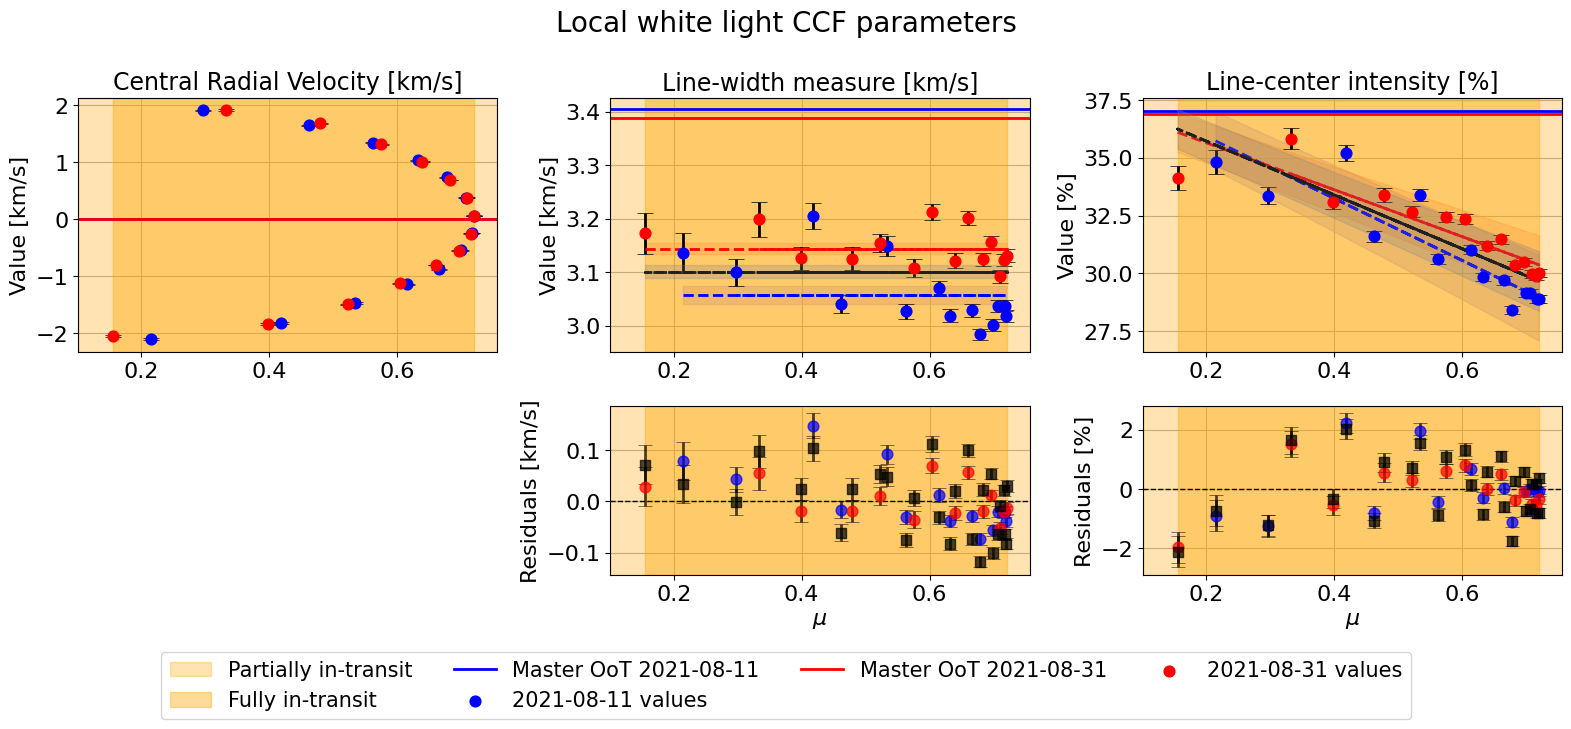

In [14]:
fit_results = mult_night.plot_parameters(param_type='mu', 
                                      fit_each_night=True, 
                                      fit_combined=True, 
                                      fit_param_indices = np.array([1, 2]),
                                      suptitle="Local white light CCF parameters")

19140it [00:12, 1536.93it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 394592 | eff(%):  4.719 | loglstar: 43.532 < 48.777 < 48.378 | logz: 31.853 +/-  0.115 | stop:  0.925]            
14447it [00:11, 1225.61it/s, batch: 7 | bound: 5 | nc: 1 | ncall: 274477 | eff(%):  5.070 | loglstar: -20.013 < -14.331 < -14.676 | logz: -21.458 +/-  0.070 | stop:  0.929]       


------------------------------
Linear vs Constant
logZ(linear)   = 31.874 ± 0.103
logZ(constant) = -21.435 ± 0.062
log Bayes factor = 53.309
Unconstrained model favored.
------------------------------


19005it [00:12, 1466.47it/s, batch: 7 | bound: 5 | nc: 1 | ncall: 391378 | eff(%):  4.723 | loglstar: 43.559 < 48.774 < 48.342 | logz: 32.618 +/-  0.111 | stop:  0.899]            
17341it [00:10, 1594.25it/s, batch: 6 | bound: 6 | nc: 1 | ncall: 353179 | eff(%):  4.762 | loglstar: -20.526 < -12.930 < -14.794 | logz: -24.225 +/-  0.088 | stop:  0.792]         


Positive vs Negative slope
logZ(m>0)  = 32.587 ± 0.100
logZ(m<0)  = -24.211 ± 0.082
log Bayes factor = -56.798
Positive slope favored.
Linear fit parameters:
m = 165.275869 +/- 1.340142
b = -0.037167 +/- 0.004493
ln_f = -3.539725 +/- 0.228468
------------------------------


19298it [00:15, 1209.36it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 398258 | eff(%):  4.715 | loglstar: 42.416 < 47.659 < 47.045 | logz: 30.816 +/-  0.111 | stop:  0.909]            
14237it [00:08, 1739.97it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 269526 | eff(%):  5.084 | loglstar: -19.901 < -14.304 < -15.062 | logz: -21.616 +/-  0.069 | stop:  0.944]        


------------------------------
Linear vs Constant
logZ(linear)   = 30.829 ± 0.101
logZ(constant) = -21.599 ± 0.064
log Bayes factor = 52.429
Unconstrained model favored.
------------------------------


18764it [00:12, 1559.66it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 386042 | eff(%):  4.726 | loglstar: 42.385 < 47.667 < 47.030 | logz: 31.905 +/-  0.107 | stop:  0.915]            
15213it [00:12, 1211.20it/s, batch: 5 | bound: 6 | nc: 1 | ncall: 304733 | eff(%):  4.818 | loglstar: -19.633 < -12.666 < -14.117 | logz: -23.936 +/-  0.100 | stop:  0.961]         


Positive vs Negative slope
logZ(m>0)  = 31.893 ± 0.099
logZ(m<0)  = -23.937 ± 0.085
log Bayes factor = -55.829
Positive slope favored.
Linear fit parameters:
m = 163.985194 +/- 1.445283
b = -0.000436 +/- 0.004610
ln_f = -3.458308 +/- 0.226794
------------------------------


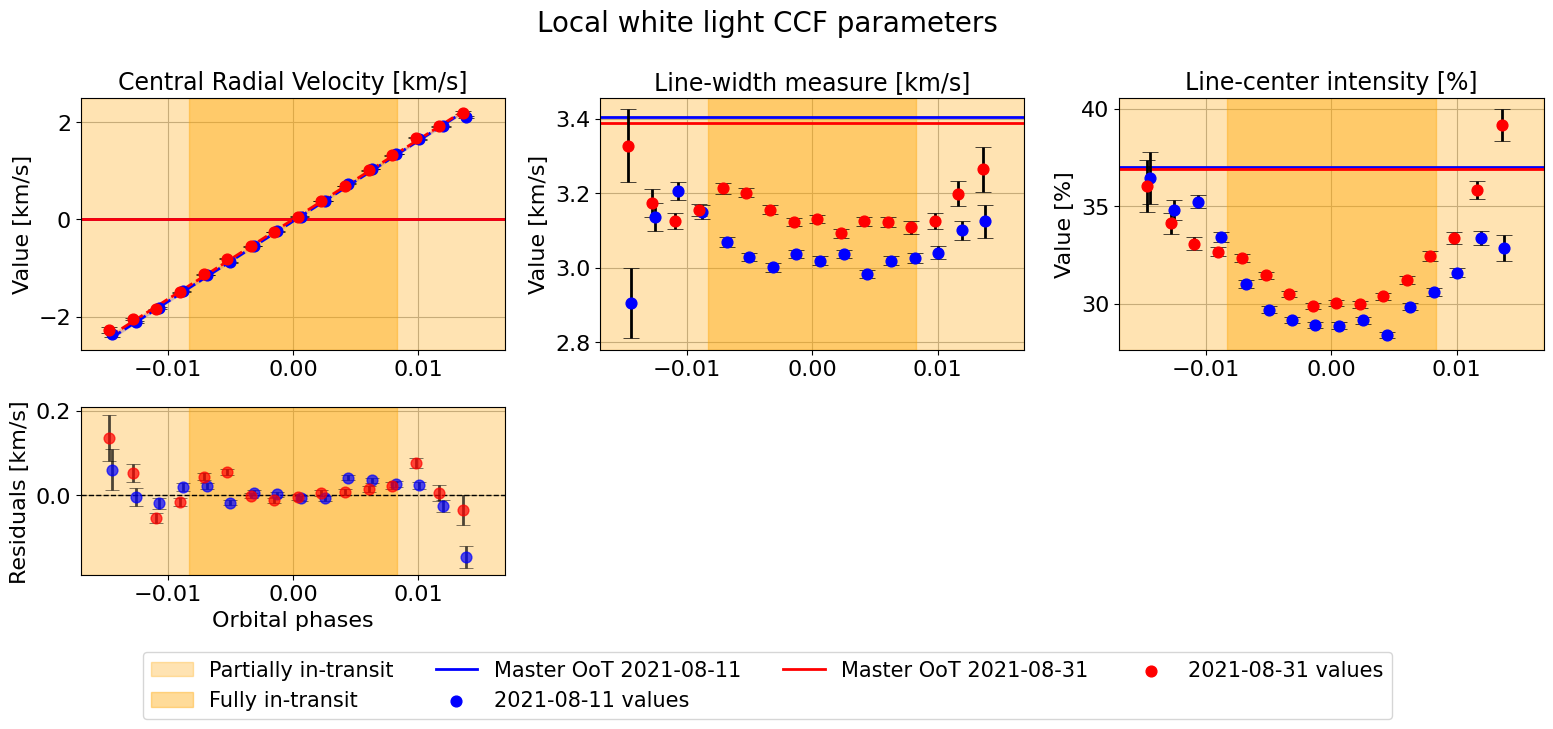

In [15]:
fit_results = mult_night.plot_parameters(param_type='phases', 
                                      fit_each_night=True, 
                                      fit_combined=False, 
                                      fit_param_indices = np.array([0]),
                                      suptitle="Local white light CCF parameters")